## Imports

In [1]:
from   pathlib import Path
import matplotlib.pyplot as plt
import pickle
import torch
import pandas as pd
# import mlflow

from neuralhydrology.evaluation     import metrics
from neuralhydrology.nh_run         import start_run, eval_run
from neuralhydrology.datasetzoo     import register_dataset
from neuralhydrology.utils.config   import Config

from custom.dataset.swisshourly import SwissHourly
register_dataset("swisshourly", SwissHourly)

# Custom functions plot_training_curves
from custom.functions.Plot import plot_training_curves, plot_validation_metrics
from custom.functions.Plot import plot_mape_horizon, plot_forecast_24h, plot_forecast_horizon_24h,plot_forecast_horizon_series
from custom.functions.utils_fla import parse_neuralhydrology_log
from custom.functions.utils_fla import info_results, mape_array, dict_without_xr_key


## Parameters of the run

In [2]:
# Initialisation of the config file, name of the experiment in the parameter experiment_name
config_file = Path("config_Name1.yml")
cfg = Config(config_file)

# Here write the name of the run if renamed run or if you want to plot the specified run, otherwise will take the run_dir created during training
# example: "expName_TimeStamp" 
runFile = None 

# list of basins, DB -> name of the basin.txt where the name of the csv is indicated
basin = "massa_RS_v1"

# Whether you want to run a training, put false to plot your specific run folder for example
TRAIN, Evaluation_TEST = True, True

save_plots_training = True

In [4]:
from pathlib import Path
import numpy as np
import torch

from neuralhydrology.utils.config import Config
from neuralhydrology.modelzoo import get_model
from neuralhydrology.datautils.utils import load_scaler

# 1) Load config
cfg = Config(Path("runs/9_5/config.yml"))

device = torch.device(cfg.device if torch.cuda.is_available() else "cpu")

# 2) Build model from config
model = get_model(cfg).to(device)   # This will construct your HandoffForecastLSTM
model.eval()

# 3) Load trained weights (.pt)
state_dict = torch.load("runs/9_5/best_model.pt", map_location=device)
model.load_state_dict(state_dict)

# 4) Load scaler from the run directory used during training
run_dir = Path("runs/9_5")   # the folder that contains model_epoch*.pt / train_data_scaler.yml
scaler = load_scaler(run_dir)       # same helper that training/evaluation uses :contentReference[oaicite:4]{index=4}

target_vars = cfg.target_variables   # ['streamflow']
feature_center = scaler["xarray_feature_center"][target_vars].to_array().values
feature_scale  = scaler["xarray_feature_scale"][target_vars].to_array().values


In [6]:
from torch.utils.data import DataLoader
from neuralhydrology.datasetzoo import get_dataset

import numpy as np
import pandas as pd

# 1) Build dataset for the test period
#    If you only have one basin, you can omit `basin=`; otherwise pass a basin ID.
ds = get_dataset(cfg=cfg, is_train=False, period="test", scaler=scaler)

loader = DataLoader(
    ds,
    batch_size=1,
    shuffle=False,
    collate_fn=ds.collate_fn
)

# target end datetime (last time step of the 72-step window)
target_end = np.datetime64("2023-07-19T17:00")  # adjust hour if needed

def move_to_device(batch, device):
    """Mimic the trainer/tester device logic for nested dicts."""
    for key in list(batch.keys()):
        if key.startswith("x_d"):
            batch[key] = {k: v.to(device) for k, v in batch[key].items()}
        elif not key.startswith("date"):
            batch[key] = batch[key].to(device)
    return batch

found = False

for batch in loader:
    # batch["date"].shape -> (1, seq_length) because you have a single frequency
    end_date = batch["date"][0, -1]

    if end_date == target_end:
        print("Found the sequence ending at:", end_date)

        data = move_to_device(batch, device)

        with torch.no_grad():
            out = model(data)

        # out["y_hat"] has shape (batch=1, forecast_len=24, n_targets=1)
        y_hat_norm = out["y_hat"].cpu().numpy()

        # Inverse scaling (same as in BaseTester) :contentReference[oaicite:6]{index=6}
        y_hat = y_hat_norm * feature_scale + feature_center

        # If you just want the 24h horizon as a 1D array:
        forecast_24h = y_hat[0, :, 0]

        # Example: print last step of forecast
        print("Last forecasted value (t+24h):", forecast_24h[-1])

        found = True
        break

if not found:
    print("No sample ending at", target_end, "was found. Check the exact timestamp.")

print(forecast_24h)

Found the sequence ending at: 2023-07-19T17:00:00.000000000
Last forecasted value (t+24h): 89.46002
[96.64729  97.69235  98.290985 95.19838  92.08588  92.13025  90.14708
 86.30258  82.44626  78.46451  74.27043  69.49718  64.50813  59.755405
 57.42123  60.58659  67.06908  71.8707   76.7366   81.26601  84.32521
 86.327545 87.94299  89.46002 ]


---

## Run

In [ ]:

if TRAIN:
    print("--- Starting the training of the model ---")
    if torch.cuda.is_available() or torch.backends.mps.is_available():
        print("Using GPU")
        run_dir = start_run(config_file=Path(config_file))
    else:
        print("Using CPU")
        run_dir = start_run(config_file=Path(config_file), gpu=-1)
    print("==================================")
    print("  Training ended successfully !   ")
    print("==================================")
else: print(" Training step skipped !")
if runFile is not None:
    run_dir = Path(f"./runs/{runFile}")

if Evaluation_TEST:
    print("\nStarting the EVALUATION on the test period:  ")
    eval_run(run_dir=run_dir, period="test", from_best=cfg.save_best_enabled)
    print("==================================")
    print("  TEST ended successfully !   ")
    print("==================================")
else: print(" Testing process skipped !")

model_str = f"model_from_best"
testPath = Path(run_dir / "test" / f"{model_str}" / "test_results.p")
with open(testPath, "rb") as fp:
    results = pickle.load(fp)




--- Starting the training of the model ---
Using GPU
2025-11-19 15:04:00: Logging to c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\Fla\Massa\07_LSTM_Handoff_v1\03_DB_RSv1_with_stations\runs\Name1_1911_150400\output.log initialized.
2025-11-19 15:04:00: ### Folder structure created at c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\Fla\Massa\07_LSTM_Handoff_v1\03_DB_RSv1_with_stations\runs\Name1_1911_150400
2025-11-19 15:04:00: ### Run configurations for Name1
2025-11-19 15:04:00: experiment_name: Name1
2025-11-19 15:04:00: base_run_dir: runs
2025-11-19 15:04:00: img_log_dir: c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\Fla\Massa\07_LSTM_Handoff_v1\03_DB_RSv1_with_stations\runs\Name1_1911_150400\img_log
2025-11-19 15:04:00: train_dir: c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\Fla\Massa\07_LSTM_Handoff_v1\03_DB_RSv1_with_stations\runs\Name1_1911_150400\train_data
2025-11-19 15:04:00: seed: 42
2025-11-19 15:04:00: device: cuda

In [ ]:
# basin="massa_RS_v1"
Metrics = dict_without_xr_key(results[basin]['1h'])
Metrics_ = Metrics.copy()

if cfg.save_in_csv and Evaluation_TEST:
    if Metrics_ is not None:
        summary_file =  Path(f"./{cfg.csv_metrics_name}.csv")
        Metrics_['experiment'] = run_dir.name

        summary_df = pd.DataFrame([Metrics_])
        
        # Append to summary file, creating it with a header if it doesn't exist
        summary_df.to_csv(f"{cfg.csv_metrics_name}.csv", mode='a', header=not summary_file.exists(), index=False)

---

In [ ]:
print("Metrics on the cuncatenated last predictions, on the Evaluation period:")
print(Metrics)

Metrics on the cuncatenated last predictions, on the Evaluation period:
{'MAPE': 10.168581008911133, 'NSE': 0.9317902326583862, 'MSE': 32.5222282409668, 'RMSE': 5.702826337963203}


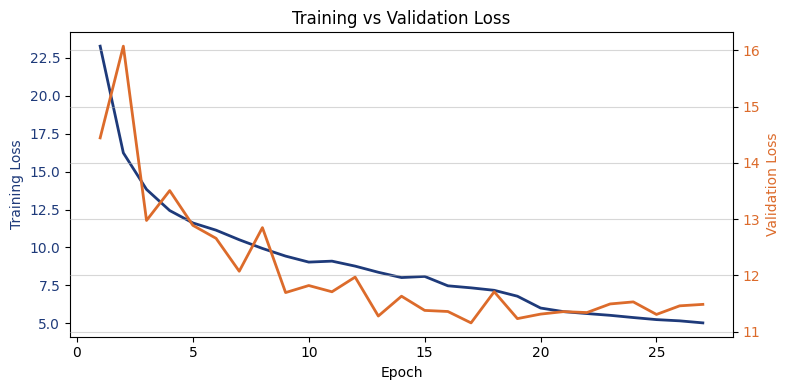

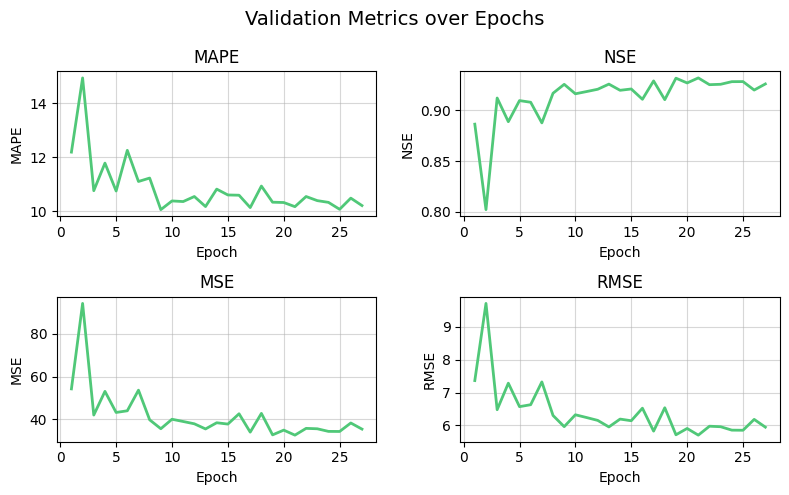

In [ ]:
# Path to your output.log file
log_path = Path(f"{run_dir}/output.log")
train_df, val_df = parse_neuralhydrology_log(log_path, verbose=False)


plot_training_curves(train_df, val_df, save_fig = save_plots_training, run_dir=run_dir)
plot_validation_metrics(val_df, save_fig = save_plots_training, run_dir=run_dir)


---

### Extract results from Test period

In [ ]:

results_ = results[basin]["1h"]["xr"]
scores = dict_without_xr_key(results[basin]['1h'])

# store only the values in numpy arrays from xarray DataArrays
y_true = results_['streamflow_obs']
y_pred = results_['streamflow_sim']

verb = False
if verb: 
    print("\n-- Calculating MAPE values for each horizon: --\n")
    mapes = mape_array(y_true, y_pred, verbose=verb)
    print("\n-- MAPE calculation per horizon completed. --\n")
else:
    mapes = mape_array(y_true, y_pred, verbose=verb)



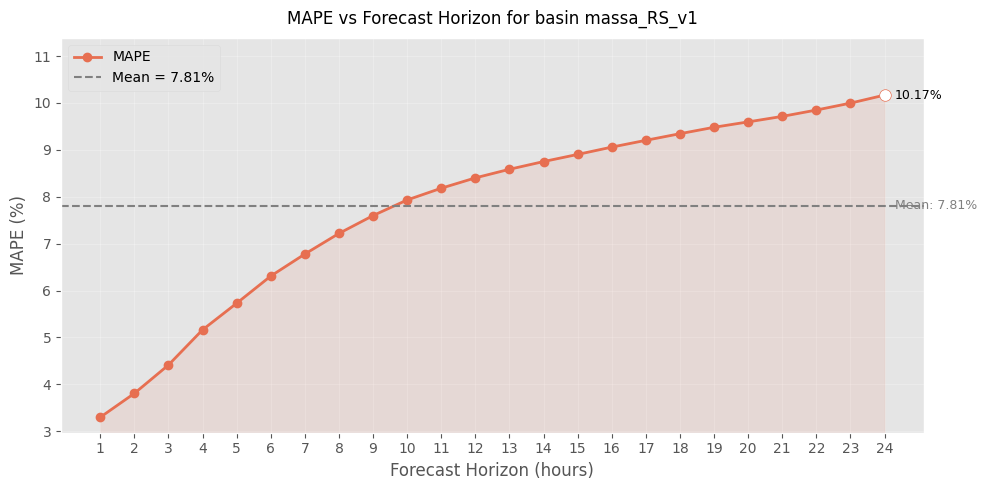

In [ ]:
plot_mape_horizon(
    mapes,
    color="#e76f51",
    title=f"MAPE vs Forecast Horizon for basin {basin}"
)


In [ ]:

scores_str = str.join(', ', [f"{key} : {scores[key]:.2f}" for key in scores])
title24 = f"Massa – {cfg.predict_last_n}h | " + scores_str

# plot_forecast_24h(measured=y_true, predicted=y_pred, title=title24, mode="list", horizons=[1, 6, cfg.predict_last_n])
plot_forecast_24h(measured=y_true, predicted=y_pred, title=title24, mode="list", horizons=[cfg.predict_last_n])


In [ ]:
# Example: visualize forecast issued on April 10, 2024, at midnight
# plot_forecast_horizon_24h(
#     issue_date="2024-08-10 00:00:00",
#     xr_ds=results_
# ).show()
# plot_forecast_horizon_24h(
#     issue_date="2024-08-10 01:00:00",
#     xr_ds=results_
# ).show()

In [ ]:
# Example to plot the forecast issued at the given time stamp and the n_forecast next predictions
# plot_forecast_horizon_series(
#     issue_date="2024-06-10 00:00:00",
#     xr_ds=results_,
#     n_forecasts=10
# ).show()

---

## Computation of all metric scores - TEST period


### Prediction at $t+24h$

In [ ]:
qobs=results_['streamflow_obs']
qsim=results_['streamflow_sim']
values = metrics.calculate_all_metrics(qobs.isel(time_step=-1), qsim.isel(time_step=-1))

for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.932
MSE: 32.522
RMSE: 5.703
KGE: 0.963
Alpha-NSE: 0.986
Beta-KGE: 0.998
Beta-NSE: -0.004
Pearson-r: 0.966
FHV: -4.112
FMS: -3.505
FLV: 12.913
Peak-Timing: nan
Peak-MAPE: 16.063
MAPE: 10.169


### Prediction at $t+7h$

In [ ]:
values = metrics.calculate_all_metrics(qobs.isel(time_step=6), qsim.isel(time_step=6))
for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.960
MSE: 18.738
RMSE: 4.329
KGE: 0.976
Alpha-NSE: 0.991
Beta-KGE: 0.990
Beta-NSE: -0.018
Pearson-r: 0.980
FHV: -1.330
FMS: -3.406
FLV: -0.997
Peak-Timing: nan
Peak-MAPE: 13.995
MAPE: 6.778
